In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from pm.utils.data import DataManager

from utils.components import (
    download_macro_factors,
    transform_macro_factors,
    calculate_all_spreads,
    align_to_portfolio
)

from utils.analyzers import (
    MacroFactorAnalyzer,
    MacroCorrelationAnalyzer,
    MacroSensitivityAnalyzer,
    MacroSituationAnalyzer
)

from utils.reporters import (
    MacroFactorReporter,
    MacroCorrelationReporter,
    MacroSensitivityReporter,
    MacroSituationReporter
)

from utils.visualizations import (
    MacroFactorVisualizer,
    MacroCorrelationVisualizer,
    MacroSensitivityVisualizer,
    MacroSituationVisualizer
)

from utils.tools import (
    MACRO_GLOBAL_FACTORS,
    FACTORS_TO_USE
)

In [2]:
ANNUAL_FACTOR = 252
ROLLING_WINDOW = 252

# Inicializar analyzers
factor_analyzer = MacroFactorAnalyzer(annual_factor=ANNUAL_FACTOR)
corr_analyzer = MacroCorrelationAnalyzer(max_lag=126)
sens_analyzer = MacroSensitivityAnalyzer(annual_factor=ANNUAL_FACTOR)
situation_analyzer = MacroSituationAnalyzer()

# Inicializar reporters
factor_reporter = MacroFactorReporter(factor_analyzer)
corr_reporter = MacroCorrelationReporter(corr_analyzer)
sens_reporter = MacroSensitivityReporter(sens_analyzer)
situation_reporter = MacroSituationReporter(situation_analyzer)

# Inicializar visualizers
factor_viz = MacroFactorVisualizer(factor_analyzer)
corr_viz = MacroCorrelationVisualizer(corr_analyzer)
sens_viz = MacroSensitivityVisualizer(sens_analyzer)
situation_viz = MacroSituationVisualizer(situation_analyzer)


In [3]:
TICKERS = ["META", "AAPL", "GOOGL", "NVDA", "MSFT"]
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

In [4]:
data_manager = DataManager()
assets_prices, _ = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name="SP500",
    start_date=START_DATE,
    end_date=END_DATE
)

returns = assets_prices.pct_change().dropna()
portfolio_returns = (returns * WEIGHTS).sum(axis=1)

print(f"Portfolio returns: {len(portfolio_returns)} observaciones")
print(f"Rango: {portfolio_returns.index[0]} a {portfolio_returns.index[-1]}")

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Período: 2020-01-01 → 2024-12-31
Portafolio descargado: 5 activos + benchmark
Portfolio returns: 1256 observaciones
Rango: 2020-01-03 00:00:00 a 2024-12-30 00:00:00


In [ ]:
factors_raw = download_macro_factors(
    factor_names=MACRO_GLOBAL_FACTORS, 
    start_date=START_DATE,
    end_date=END_DATE,
    progress=True
)

factors_dict, factors_df = transform_macro_factors(
    factors_raw,
    target_index=portfolio_returns.index
)

spreads_df = calculate_all_spreads(factors_df)

if not spreads_df.empty:
    print(f"Spreads calculados: {spreads_df.shape[1]}")
    print(f"   {', '.join(spreads_df.columns)}")
    factors_complete = pd.concat([factors_df, spreads_df], axis=1)
else:
    print("No hay spreads calculados")
    factors_complete = factors_df.copy()

factors_aligned = align_to_portfolio(factors_complete, portfolio_returns)
factors_for_analysis = factors_aligned[FACTORS_TO_USE + list(spreads_df.columns)].dropna()

print(f"\nFactores para análisis: {factors_for_analysis.shape[1]} factores")
print(f"Observaciones: {factors_for_analysis.shape[0]}")

[*********************100%***********************]  20 of 20 completed


[Macro] OIL: 1 valores <= 0 encontrados, reemplazados por NaN
Spreads calculados: 3
   yield_curve_30_10y, credit_spread_hy, credit_spread_hy_lqd

Factores para análisis: 14 factores
Observaciones: 1256


                      ANÁLISIS DE FACTORES MACRO                      
RESUMEN DE REGRESIÓN
  Alpha (diario):             0.0579%
  Alpha (anual):               15.72%
  R²:                          0.756
  R² ajustado:                 0.754
  Observaciones:                1256
  Interpretación:           Excelente - genera alpha significativo
FACTOR LOADINGS (BETAS)
Factor                     Beta     t-stat    p-value Signif    
SP500                    1.6046     17.385     0.0000 ***       
HYG                     -0.2280     -4.179     0.0000 ***       
credit_spread_hy        -0.2224     -5.519     0.0000 ***       
yield_curve_30_10y       0.1354      1.021     0.3074           
LQD                     -0.1307     -4.346     0.0000 ***       
credit_spread_hy_lqd    -0.0973     -1.563     0.1180           
RATE_30Y                 0.0942      0.858     0.3910           
DXY                      0.0496      0.506     0.6129           
RATE_10Y                -0.0412     -0.550   

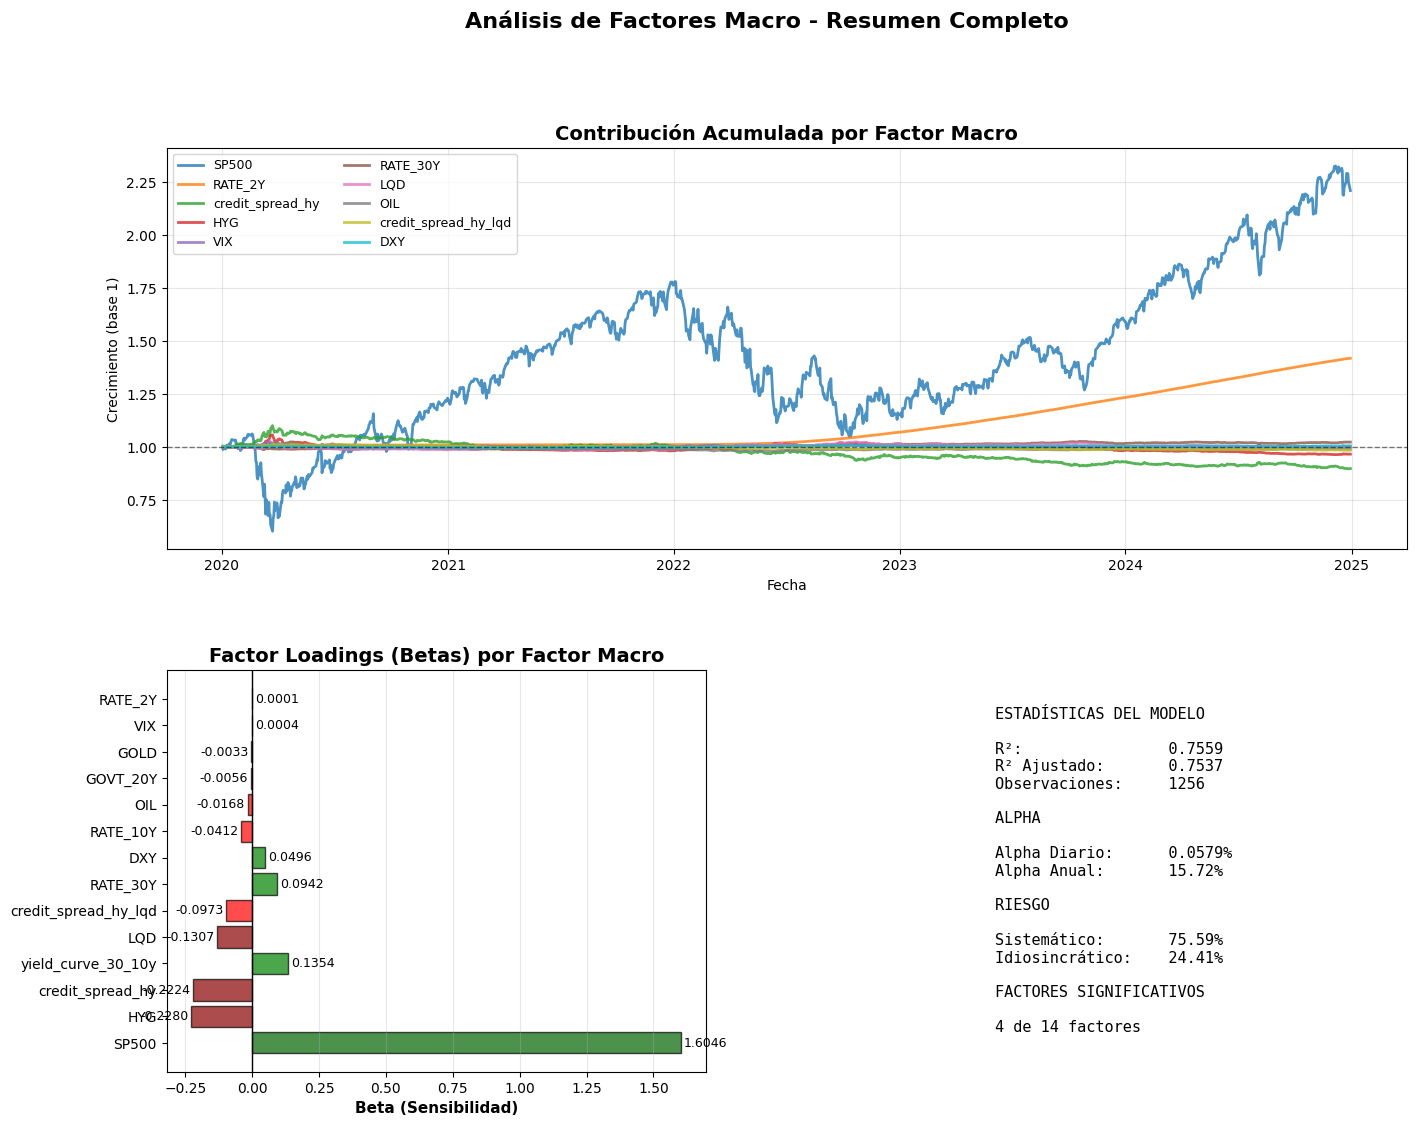

In [6]:
factor_results = factor_analyzer.analyze(
    portfolio_returns,
    factors_for_analysis,
    use_hac=True
)

factor_reporter.print_analysis(factor_results)
fig = factor_viz.plot_factor_analysis(factor_results, top_n=10)
plt.show()

                   ANÁLISIS DE CORRELACIONES MACRO                    
MEJORES CORRELACIONES (con lag óptimo)
Factor                   Corr    Lag     t-stat    p-value
SP500                   0.860      0     23.807     0.0000
VIX                    -0.644      0    -16.986     0.0000
HYG                     0.637      0     10.124     0.0000
credit_spread_hy        0.402      0      7.962     0.0000
credit_spread_hy_lqd    0.345      0      6.432     0.0000
LQD                     0.304      0      4.503     0.0000
DXY                    -0.181      0     -3.726     0.0002
OIL                     0.158      0      3.406     0.0007
GOLD                    0.109      0      2.779     0.0055
GOVT_20Y               -0.099      9     -2.427     0.0152
FACTORES LAGGING (siguen al portafolio)
  • GOVT_20Y: 9 días retrasado (corr=-0.099)
  • RATE_30Y: 36 días retrasado (corr=0.084)
  • RATE_10Y: 41 días retrasado (corr=-0.082)
  • RATE_2Y: 125 días retrasado (corr=0.046)


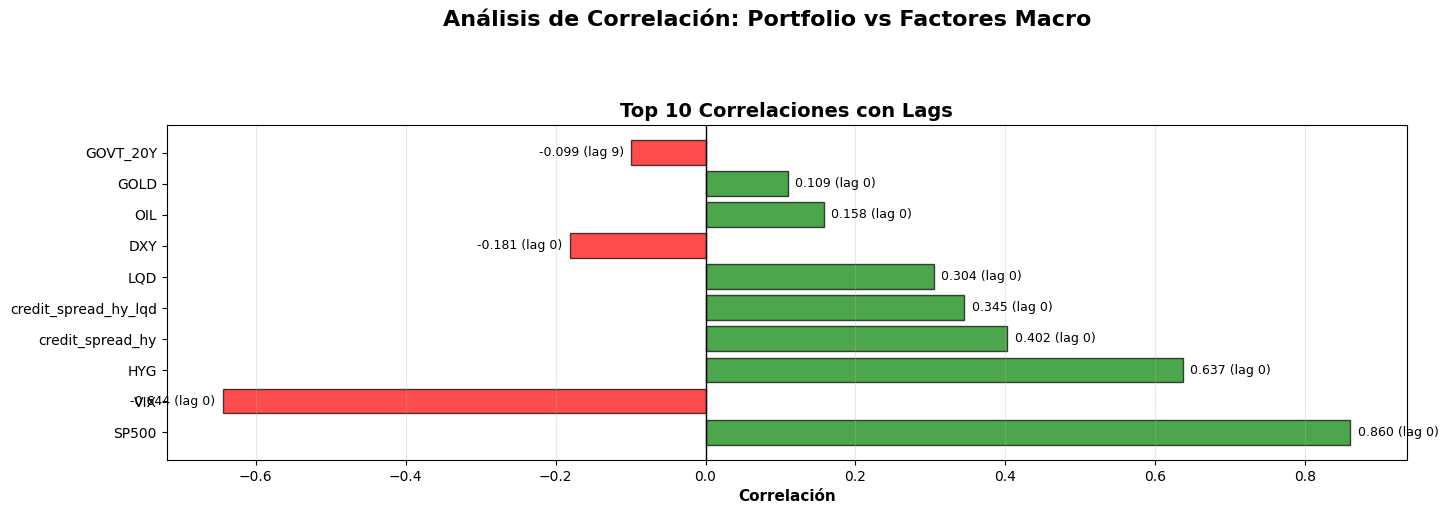

In [7]:
corr_results = corr_analyzer.analyze(
    portfolio_returns,
    factors_for_analysis
)

corr_reporter.print_analysis(corr_results)
fig = corr_viz.plot_correlation_analysis(corr_results, top_n=10)
plt.show()

                   ANÁLISIS DE SENSIBILIDADES MACRO                   
EXPOSICIONES POR MAGNITUD
ALTA EXPOSICIÓN (|β| > 0.5)
  ↑ SP500: β =   1.605
EXPOSICIÓN MODERADA (0.2 ≤ |β| ≤ 0.5)
  ↓ HYG: β =  -0.228
  ↓ credit_spread_hy: β =  -0.222
BAJA EXPOSICIÓN (|β| < 0.2)
    yield_curve_30_10y: β =   0.135
    LQD: β =  -0.131
    credit_spread_hy_lqd: β =  -0.097
    RATE_30Y: β =   0.094
    DXY: β =   0.050
FACTOR DOMINANTE
  SP500: β = 1.605
  Interpretación: Exposición muy alta


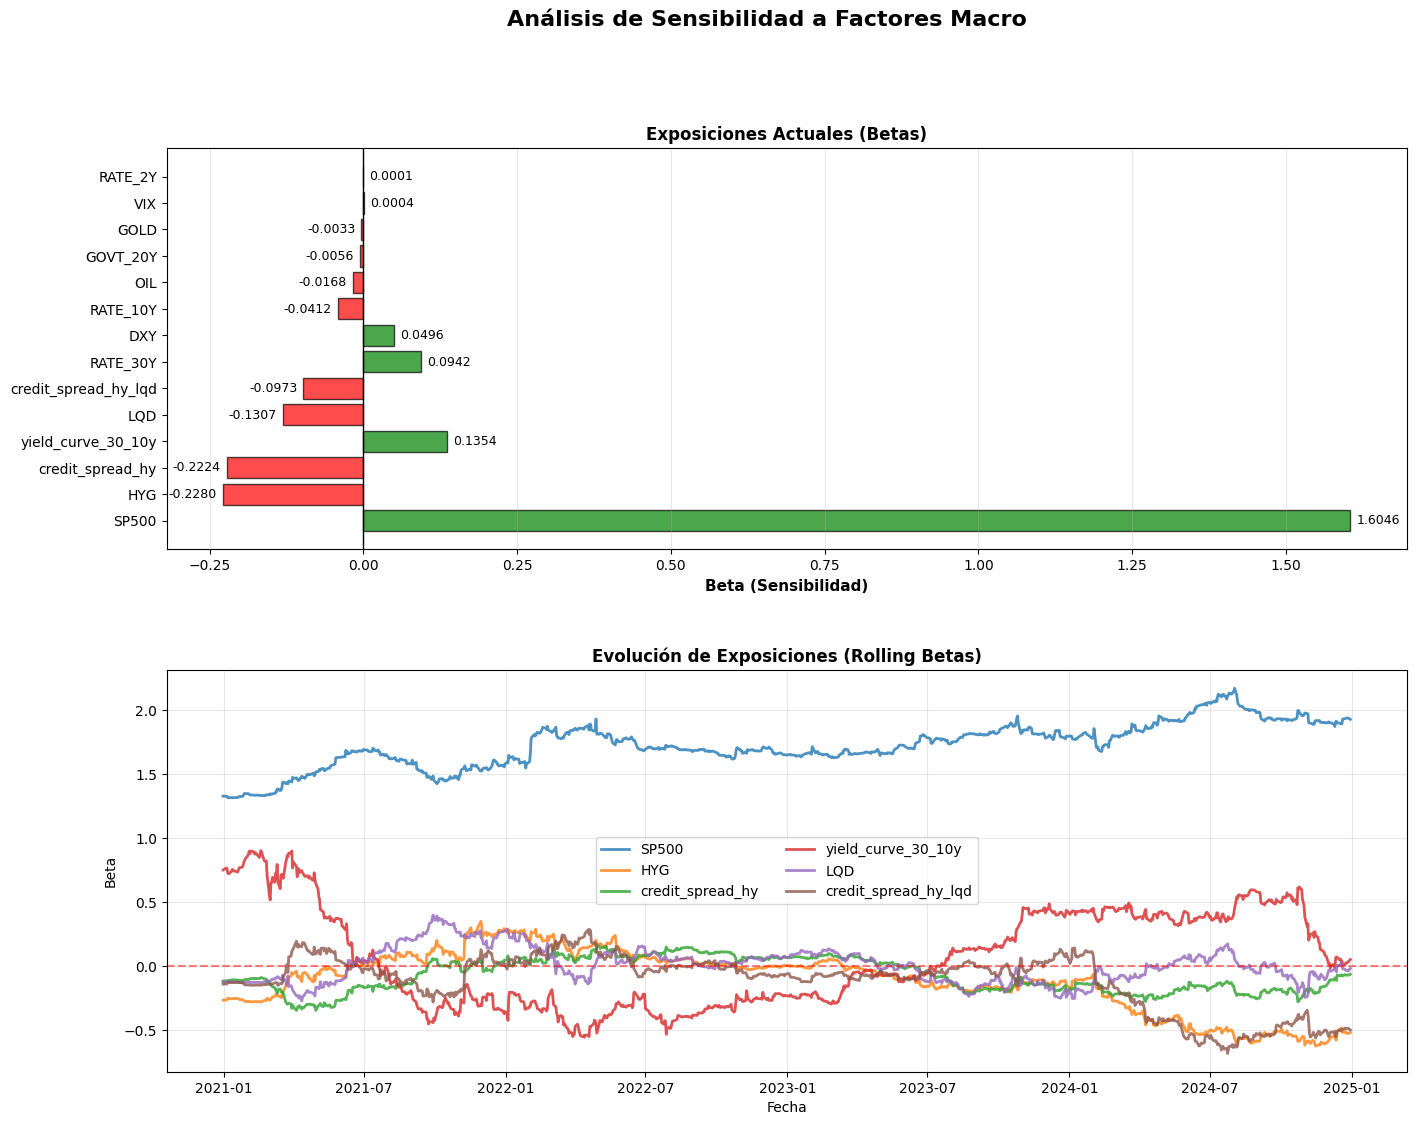

In [8]:
sens_results = sens_analyzer.analyze(
    portfolio_returns,
    factors_for_analysis
)

sens_reporter.print_analysis(sens_results)

rolling_betas = sens_analyzer.analyze_rolling(
    portfolio_returns,
    factors_for_analysis,
    window=ROLLING_WINDOW
)

fig = sens_viz.plot_sensitivity_analysis(sens_results, rolling_betas=rolling_betas)
plt.show()

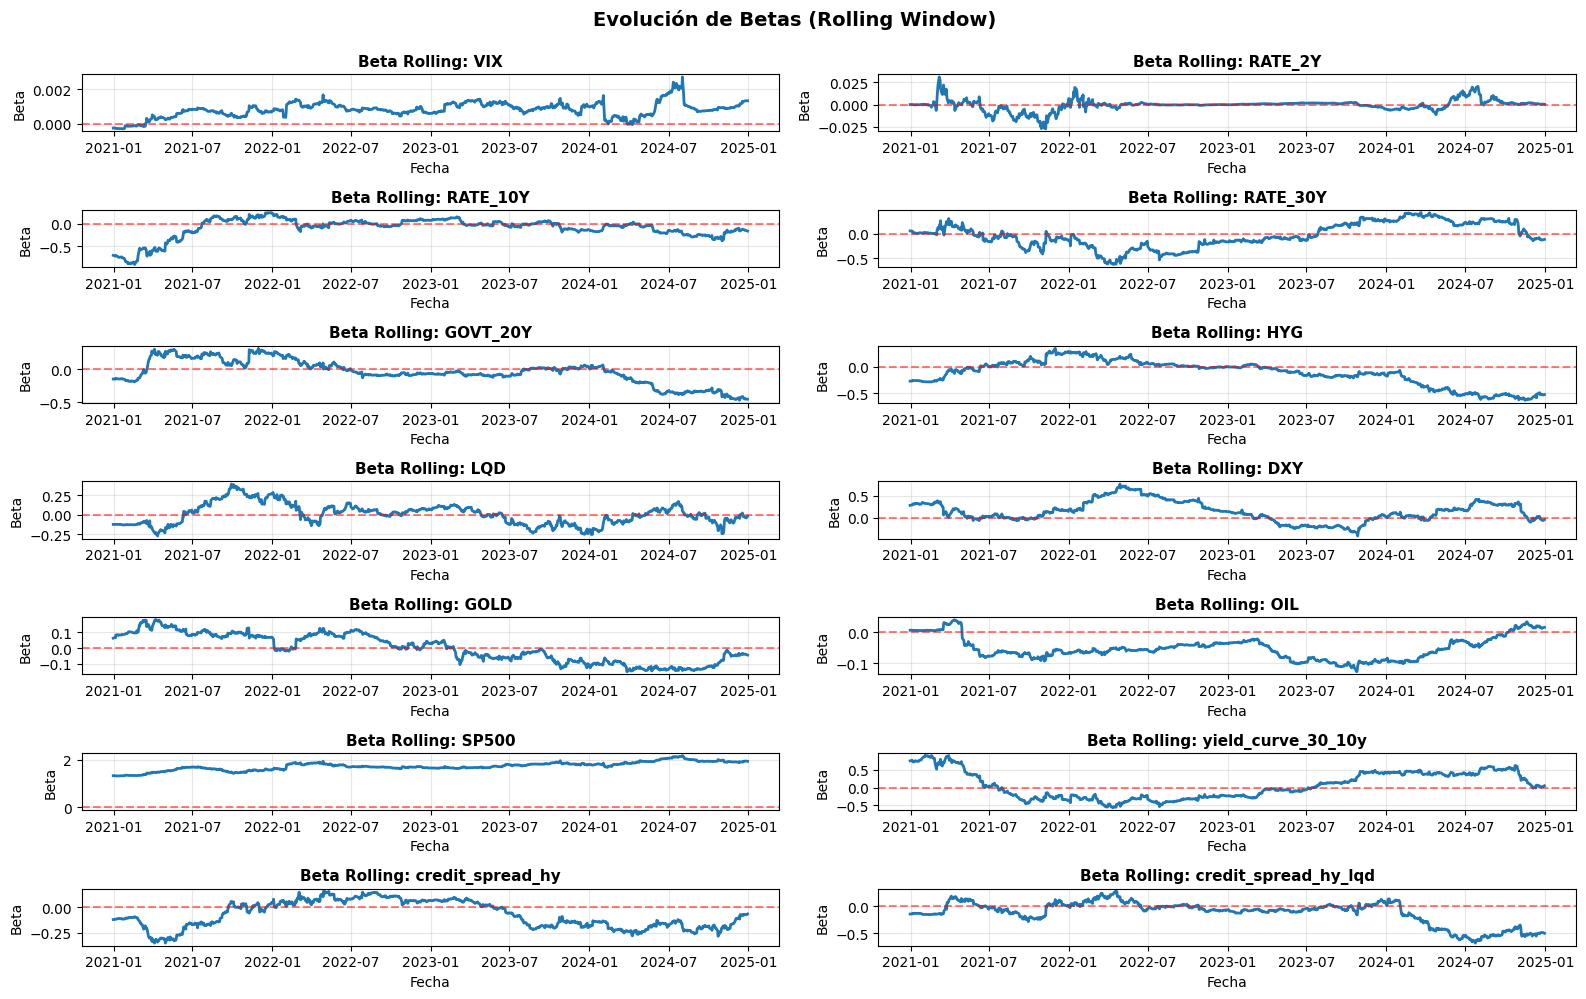

                      ANÁLISIS DE FACTORES MACRO                      
RESUMEN DE REGRESIÓN
  Alpha (diario):             0.0579%
  Alpha (anual):               15.72%
  R²:                          0.756
  R² ajustado:                 0.754
  Observaciones:                1256
  Interpretación:           Excelente - genera alpha significativo
FACTOR LOADINGS (BETAS)
Factor                     Beta     t-stat    p-value Signif    
SP500                    1.6046     17.385     0.0000 ***       
HYG                     -0.2280     -4.179     0.0000 ***       
credit_spread_hy        -0.2224     -5.519     0.0000 ***       
yield_curve_30_10y       0.1354      1.021     0.3074           
LQD                     -0.1307     -4.346     0.0000 ***       
credit_spread_hy_lqd    -0.0973     -1.563     0.1180           
RATE_30Y                 0.0942      0.858     0.3910           
DXY                      0.0496      0.506     0.6129           
RATE_10Y                -0.0412     -0.550   

In [9]:
fig = sens_viz.plot_rolling_betas(rolling_betas, figsize=(16, 10))
plt.show()
factor_reporter.print_analysis(factor_results)

                        SITUACIÓN MACROECONÓMICA GLOBAL                         
RESUMEN EJECUTIVO

  Nivel de riesgo global: 🟢 BAJO

  ✅ No se detectan factores de riesgo significativos
CURVA DE TIPOS DE INTERÉS (USA)

  Niveles actuales:
     10Y:   4.55%
      2Y:   4.18%
     30Y:   4.76%
      5Y:   4.37%

  Spreads:
    🟢     10Y-2Y:  +0.36 pp
    🟢     10Y-5Y:  +0.18 pp
    🟢    30Y-10Y:  +0.22 pp

  💡 NORMAL - Crecimiento estable
SEÑALES DE INFLACIÓN (Commodities)

  Cambio últimos 12 meses:
    🔴 Oro         :  +26.36%
    🔴 Plata       :  +22.02%
    🟢 Petróleo    :   -0.92%
    🟢 Cobre       :   +4.25%

  💡 MODERADA - Inflación controlada
     Cambio promedio: +12.93%
CONDICIONES DE CRÉDITO Y VOLATILIDAD

  🟢 VIX (volatilidad):        17.40

  💡 NORMAL - Volatilidad controlada

  Niveles ETFs crédito:
    HYG (High Yield):        $  74.26
    LQD (Investment Grade):  $ 102.38
BONOS SOBERANOS GLOBALES
{'Región':<15} {'Nivel':<12} {'1 Mes':<12} {'1 Año':<12}
  Alemania        

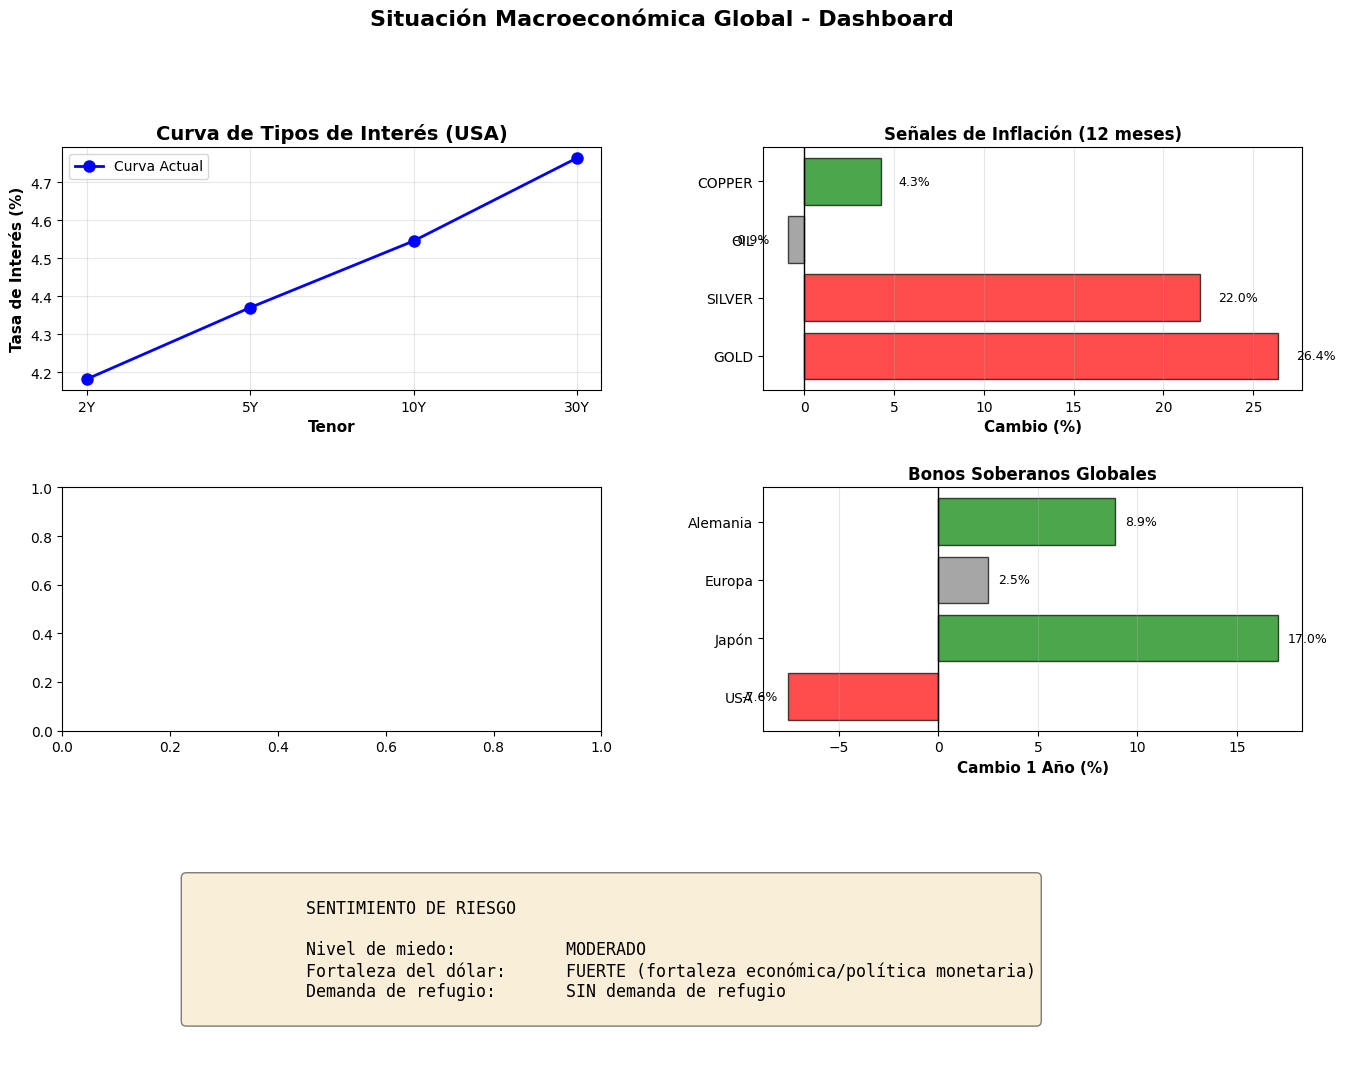

In [10]:
situation_results = situation_analyzer.analyze(factors_raw)
situation_reporter.print_situation(situation_results)
fig = situation_viz.plot_macro_situation(situation_results)
plt.show()